# Load Sentinel-3 data from the Planetary Computer STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/catalog).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

Now, we first import everything we need:

In [1]:
%%time
import xarray as xr
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 6.37 s, sys: 571 ms, total: 6.94 s
Wall time: 5.15 s


In [2]:
xr.set_options(display_expand_attrs=False)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-pc-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-pc`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [3]:
%%time
store_params = get_data_store_params_schema("stac-pc-ardc")
store_params

CPU times: user 663 ms, sys: 105 ms, total: 767 ms
Wall time: 767 ms


In [4]:
%%time
store = new_data_store("stac-pc-ardc")

CPU times: user 38.1 ms, sys: 8.22 ms, total: 46.3 ms
Wall time: 152 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [5]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 37 μs, sys: 4 μs, total: 41 μs
Wall time: 45.1 μs


['sentinel-2-l2a',
 'sentinel-3-synergy-syn-l2-netcdf',
 'sentinel-3-slstr-lst-l2-netcdf']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [6]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-synergy-syn-l2-netcdf")
open_params

CPU times: user 286 μs, sys: 0 ns, total: 286 μs
Wall time: 311 μs


The store supports the collection `"sentinel-3-synergy-syn-l2-netcdf"`, from which ARDC can be built as shown in the next cell. 

In [7]:
%%time
ds = store.open_data(
    data_id="sentinel-3-synergy-syn-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn-oa01-reflectance", "syn-oa02-reflectance"],
)
ds

CPU times: user 31.7 s, sys: 36.2 s, total: 1min 7s
Wall time: 4min 33s


<xarray.Dataset> Size: 214MB
Dimensions:       (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time          (time) datetime64[s] 16B 2020-07-31T09:46:20 2020-08-01T09:...
  * lat           (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon           (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref   int64 8B 0
Data variables:
    SDR_Oa01      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa01_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    CLOUD_flags   (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    OLC_flags     (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SLN_flags     (time, lat, lon) uint32 19MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SLO_flags     (time, lat, lon) uint32 19MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SYN_flags     (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (17)

We can plot the spectral band 0 from the  OLCI Instrument as an example.

CPU times: user 16.1 s, sys: 10.5 s, total: 26.6 s
Wall time: 52.3 s


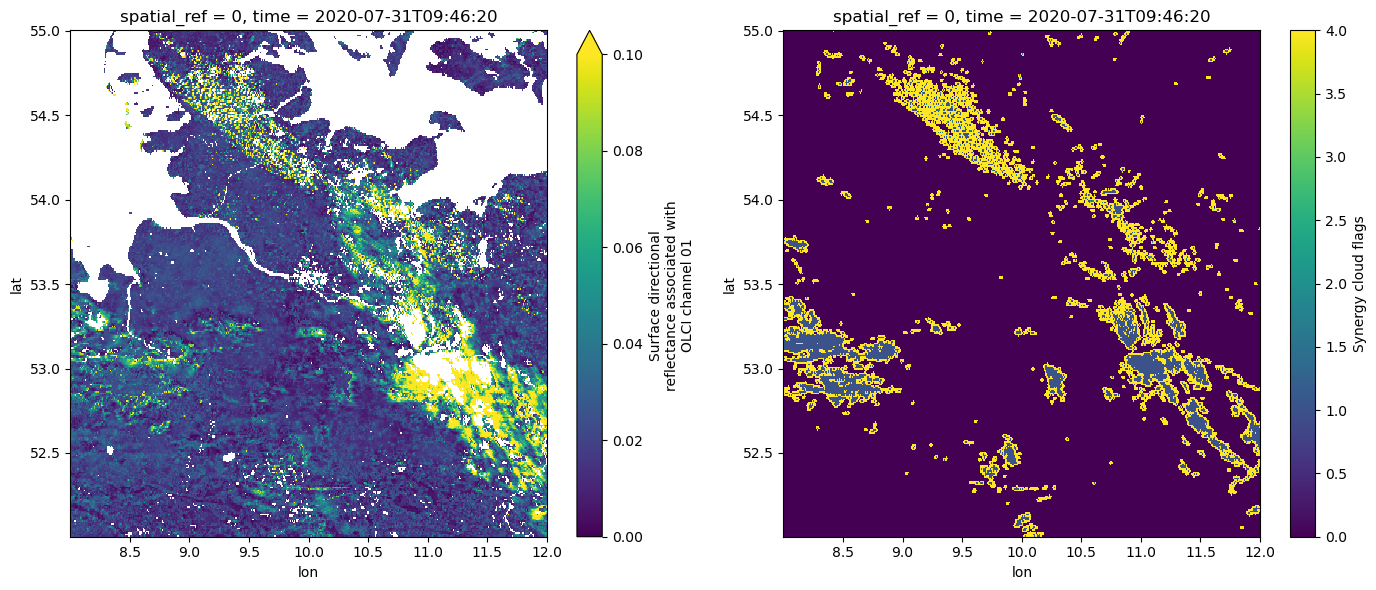

In [9]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa01[::4, ::4].plot(ax=ax[0], vmax=0.1, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1])
plt.tight_layout()

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-slstr-lst-l2-netcdf"`).

In [5]:
%%time
ds = store.open_data(
    data_id="sentinel-3-slstr-lst-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-08-01", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
)
ds

CPU times: user 1min 12s, sys: 32.2 s, total: 1min 44s
Wall time: 1min 52s


<xarray.Dataset> Size: 90MB
Dimensions:                      (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time                         (time) datetime64[s] 16B 2020-08-01T09:41:52...
  * lat                          (lat) float64 11kB 55.0 55.0 ... 52.0 52.0
  * lon                          (lon) float64 14kB 8.001 8.003 ... 12.0 12.0
    spatial_ref                  int64 8B 0
Data variables:
    LST                          (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    bayes_in                     (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    probability_cloud_single_in  (time, lat, lon) int16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    bayes_orphan_in              (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    cloud_in                     (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    confidence_in                (time, lat, lon) uint16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    pointing_in                  (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    probability_cloud_dual_in    (time, lat, lon) int16 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (19)

CPU times: user 17.7 s, sys: 6.11 s, total: 23.8 s
Wall time: 9.95 s


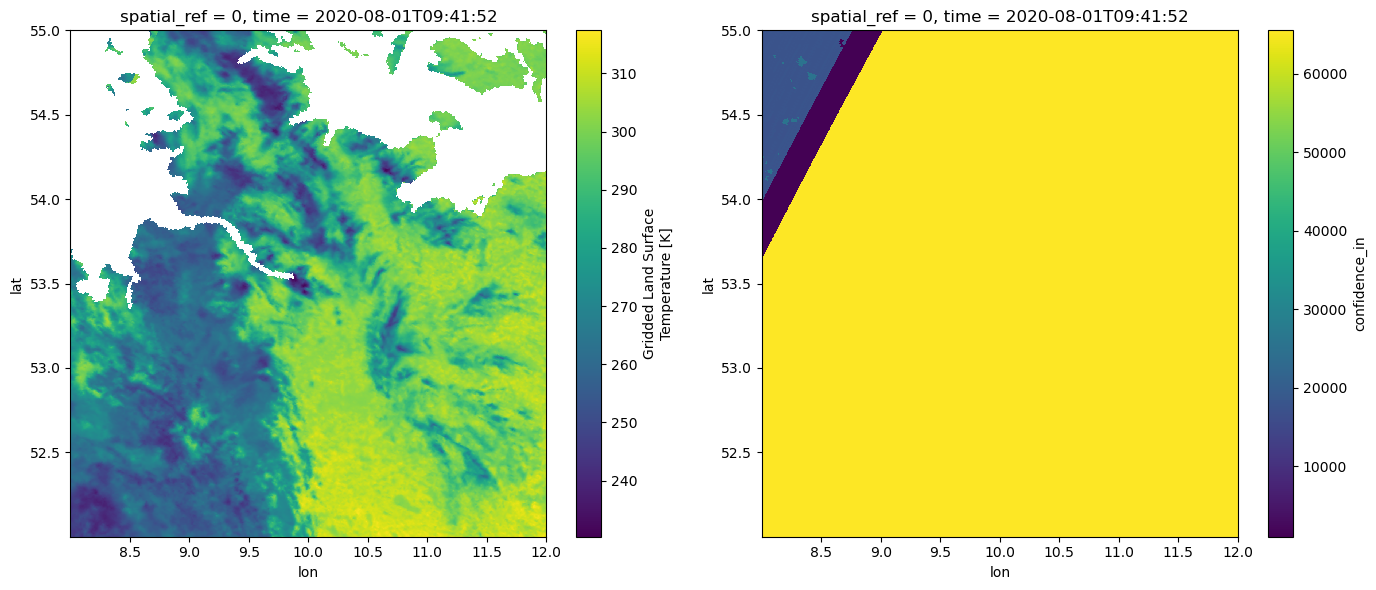

In [12]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.isel(time=0).plot(ax=ax[0])
ds.confidence_in.isel(time=0).plot(ax=ax[1])
plt.tight_layout()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [13]:
%%time
store_params = get_data_store_params_schema("stac-pc")
store_params

CPU times: user 62 μs, sys: 0 ns, total: 62 μs
Wall time: 69.1 μs


To initialize the CDSE STAC data store, execute the following cell.

In [14]:
%%time
store = new_data_store("stac-pc")

CPU times: user 34.1 ms, sys: 44.9 ms, total: 79 ms
Wall time: 139 ms


We can search for Sentinel-3 SYN products, as shwon below:

In [15]:
search_params = store.get_search_params_schema()
search_params

In [16]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-synergy-syn-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

[{'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200705T094658_20200705T094958_0180_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.5134, 39.5428, 18.4889, 52.4499],
  'time_range': ('2020-07-05T09:46:57.969790Z',
   '2020-07-05T09:49:57.969790Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'dataset',
  'bbox': [8.3152, 39.5562, 28.3241, 52.4659],
  'time_range': ('2020-07-05T09:07:31.314318Z',
   '2020-07-05T09:10:31.314318Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200704T101309_20200704T101609_0179_060_122_2160',
  'data_type': 'dataset',
  'bbox': [-8.0581, 39.5416, 11.943, 52.4497],
  'time_range': ('2020-07-04T10:13:08.862747Z',
   '2020-07-04T10:16:08.862747Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200704T093342_20200704T093642_0179_040_364_2160',
  'data_

Below, the parameters for the `open_data` method can be viewed.

In [17]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [18]:
%%time
ds = store.open_data(descriptors[0].data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 2.01 s, sys: 1.13 s, total: 3.14 s
Wall time: 6.71 s


<xarray.Dataset> Size: 5GB
Dimensions:      (y: 4091, x: 4865)
Coordinates:
    lat          (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    lon          (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/31)
    SDR_S1N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3N      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3O      (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...           ...
    SDR_Oa21     (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    CLOUD_flags  (y, x) uint8 20MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    OLC_flags    (y, x) uint16 40MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLN_flags    (y, x) uint32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLO_flags    (y, x) uint32 80MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SYN_flags    (y, x) uint16 40MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 6.37 s, sys: 9.29 s, total: 15.7 s
Wall time: 49 s


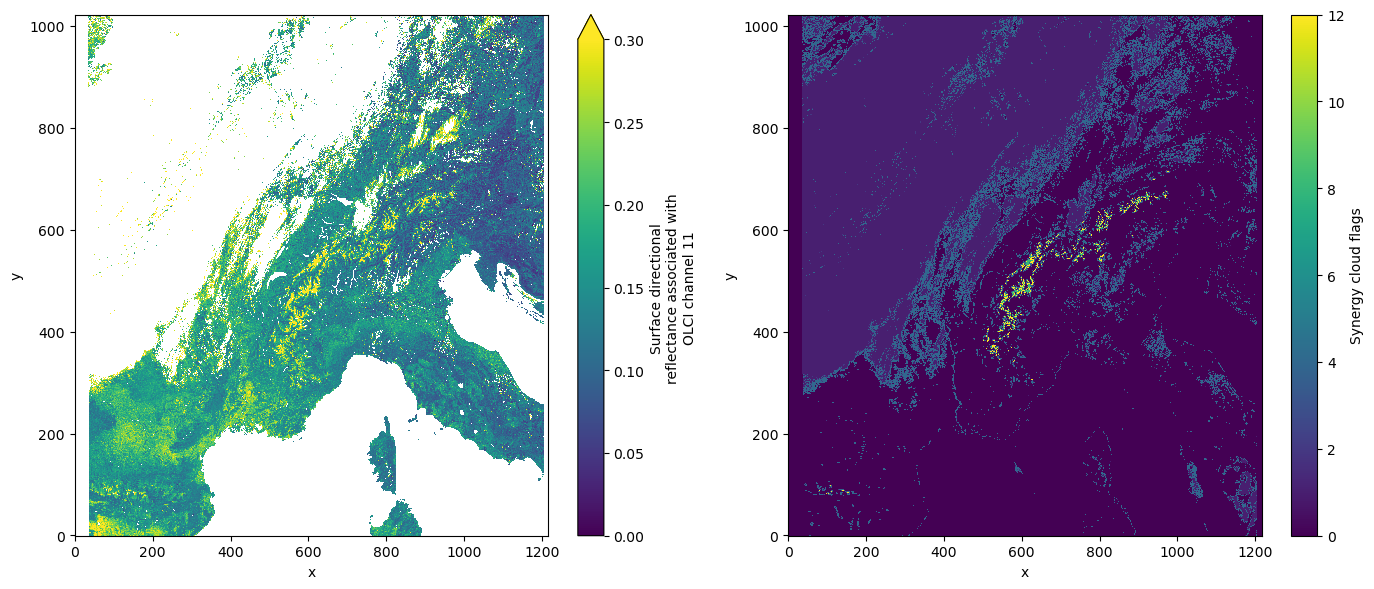

In [19]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa11[::4, ::4].plot(ax=ax[0], vmax=0.3, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1])
plt.tight_layout()

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [20]:
%%time
ds = store.open_data(descriptors[0].data_id)
ds

CPU times: user 8.82 s, sys: 8.83 s, total: 17.7 s
Wall time: 47.2 s


<xarray.Dataset> Size: 13GB
Dimensions:       (lon: 5787, lat: 5071)
Coordinates:
  * lon           (lon) float64 46kB -1.513 -1.51 -1.506 ... 18.48 18.48 18.49
  * lat           (lat) float64 41kB 52.45 52.45 52.44 ... 39.55 39.55 39.54
    spatial_ref   int64 8B 0
Data variables: (12/57)
    SDR_S1N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...            ...
    SDR_Oa21_err  (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    CLOUD_flags   (lat, lon) uint8 29MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    OLC_flags     (lat, lon) uint16 59MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLN_flags     (lat, lon) uint32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SLO_flags     (lat, lon) uint32 117MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SYN_flags     (lat, lon) uint16 59MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 1min 27s, sys: 37.6 s, total: 2min 4s
Wall time: 56.9 s


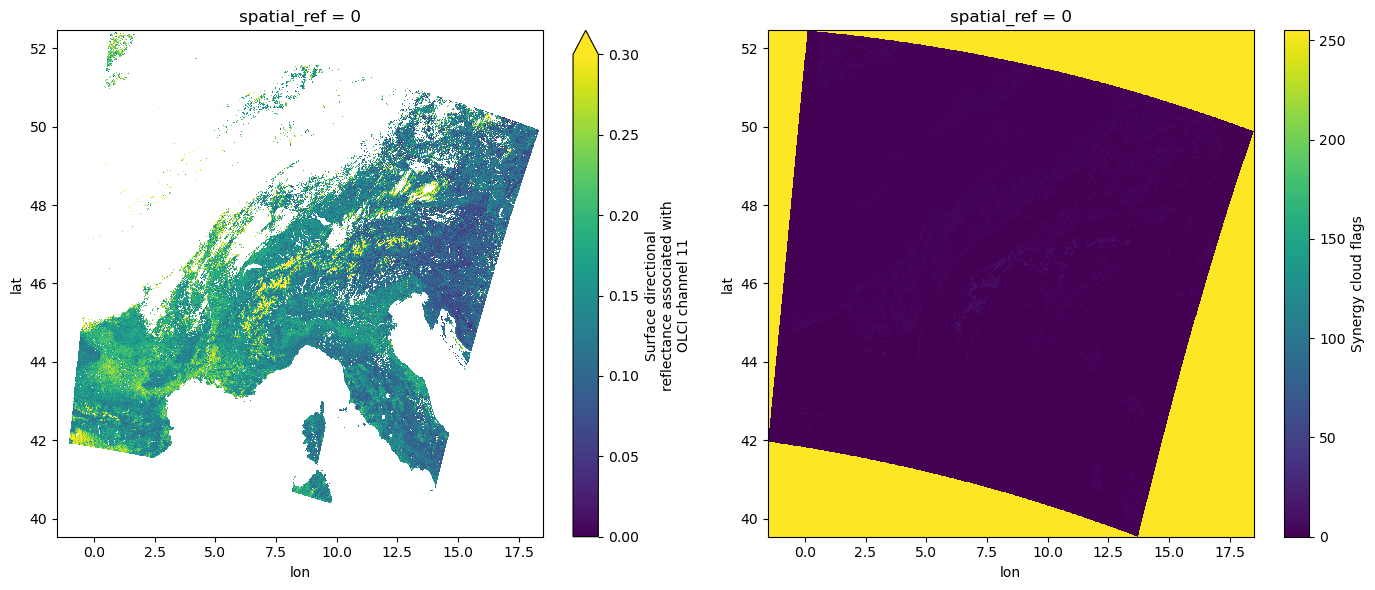

In [21]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.SDR_Oa11[::4, ::4].plot(ax=ax[0], vmax=0.3, vmin=0.)
ds.CLOUD_flags[::4, ::4].plot(ax=ax[1], vmax=4)
plt.tight_layout()

The same we can do the Sentinel-3 SLSTR Land Surface Temperature

In [22]:
%%time
descriptors = list(
    store.search_data(
        collections=["sentinel-3-slstr-lst-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

CPU times: user 1.44 s, sys: 1.09 s, total: 2.53 s
Wall time: 7.79 s


[{'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T210953_20200705T211253_0180_060_143_0720',
  'data_type': 'dataset',
  'bbox': [-6.5275, 41.1064, 16.7602, 54.486],
  'time_range': ('2020-07-05T21:09:52.587459Z',
   '2020-07-05T21:12:52.587459Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T203026_20200705T203326_0179_040_385_0720',
  'data_type': 'dataset',
  'bbox': [3.286, 41.097, 26.5757, 54.4859],
  'time_range': ('2020-07-05T20:30:25.939839Z',
   '2020-07-05T20:33:25.939839Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T094658_20200705T094958_0179_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.7734, 39.1027, 20.6113, 52.4606],
  'time_range': ('2020-07-05T09:46:57.969633Z',
   '2020-07-05T09:49:57.969633Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'da

In [23]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

In [24]:
%%time
ds = store.open_data(descriptors[2].data_id, apply_rectification=False)
ds

CPU times: user 981 ms, sys: 607 ms, total: 1.59 s
Wall time: 3.11 s


<xarray.Dataset> Size: 63MB
Dimensions:                      (y: 1200, x: 1500)
Coordinates:
    lat                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST                          (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_in                     (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_single_in  (y, x) int16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_orphan_in              (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    cloud_in                     (y, x) uint16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    confidence_in                (y, x) uint16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    pointing_in                  (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_dual_in    (y, x) int16 4MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 5.83 s, sys: 3.56 s, total: 9.38 s
Wall time: 15.1 s


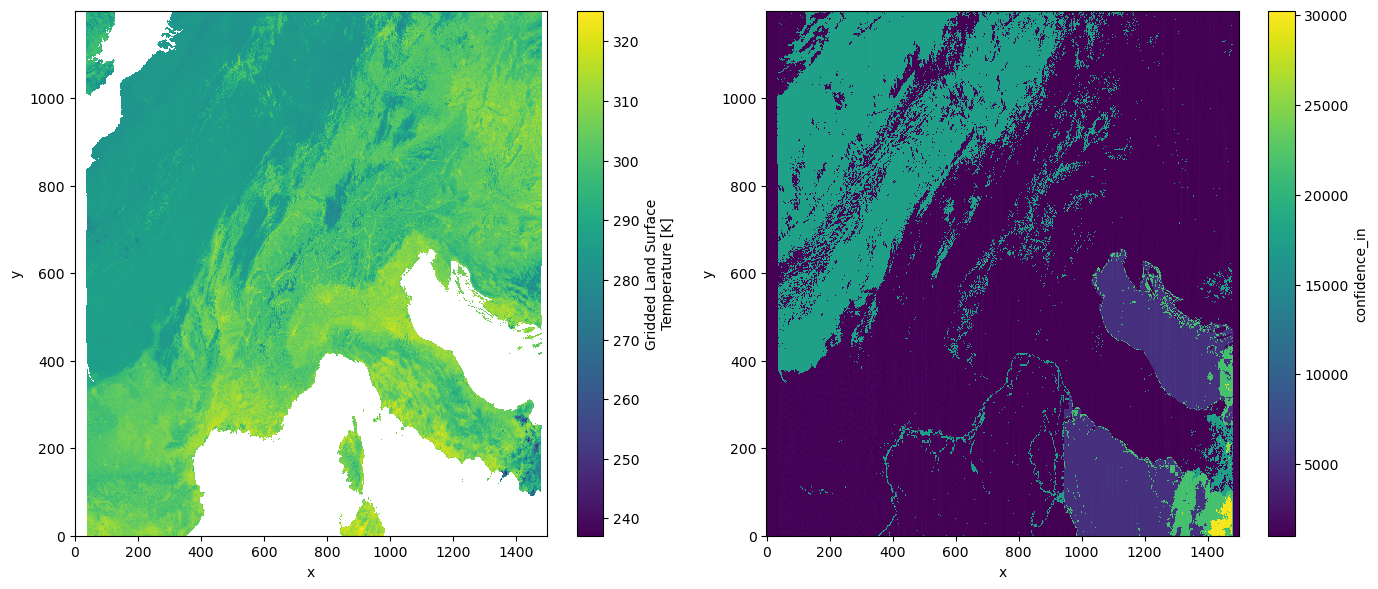

In [25]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.confidence_in.plot(ax=ax[1])
plt.tight_layout()

In [26]:
%%time
ds = store.open_data(descriptors[2].data_id)
ds

CPU times: user 6.14 s, sys: 2.33 s, total: 8.47 s
Wall time: 5.18 s


<xarray.Dataset> Size: 52MB
Dimensions:                      (lon: 1760, lat: 1546)
Coordinates:
  * lon                          (lon) float64 14kB -1.773 -1.761 ... 20.61
  * lat                          (lat) float64 12kB 52.46 52.45 ... 39.11 39.1
    spatial_ref                  int64 8B 0
Data variables:
    LST                          (lat, lon) float64 22MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_in                     (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_single_in  (lat, lon) int16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    bayes_orphan_in              (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    cloud_in                     (lat, lon) uint16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    confidence_in                (lat, lon) uint16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    pointing_in                  (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    probability_cloud_dual_in    (lat, lon) int16 5MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 15.4 s, sys: 3.28 s, total: 18.7 s
Wall time: 7.28 s


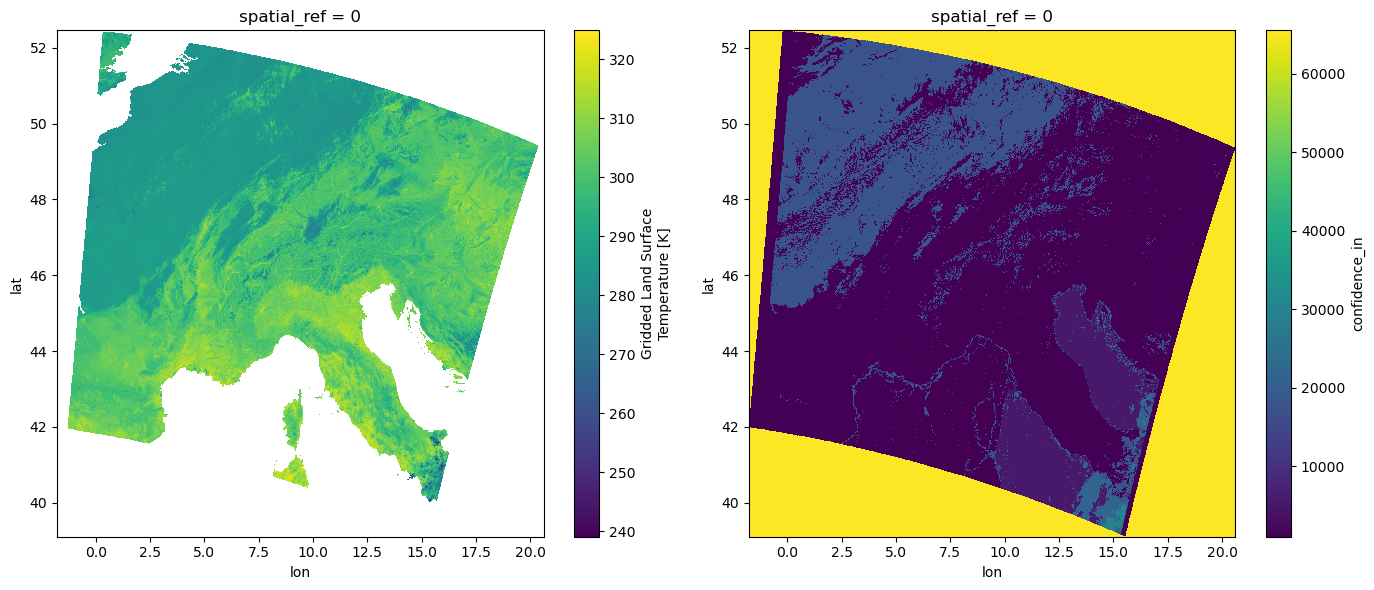

In [27]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.confidence_in.plot(ax=ax[1])
plt.tight_layout()